# **PART A – Visualization of Activation Functions**

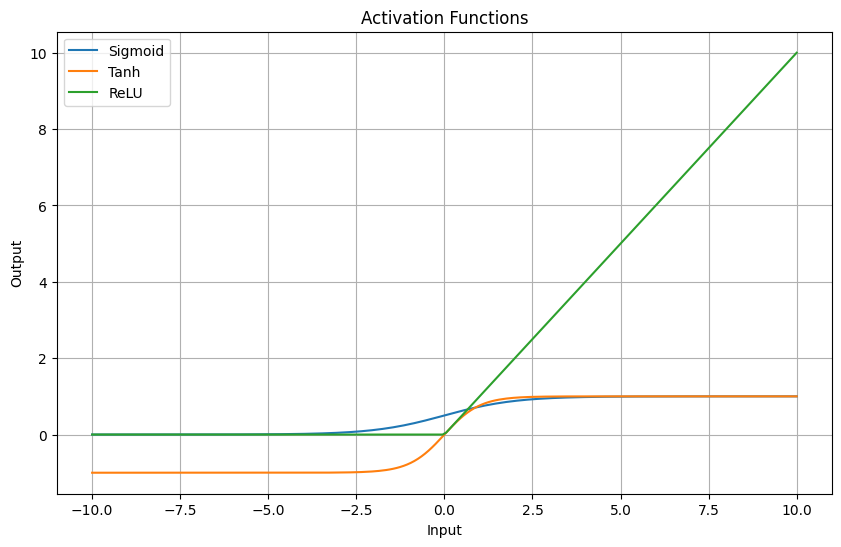

In [1]:
#SHAILESH GOWTHAM - 24BAD108

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.figure(figsize=(10,6))
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")
plt.plot(x, relu, label="ReLU")
plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.show()

# **PART B – Performance Comparison of Activation Functions**

In [2]:
#SHAILESH GOWTHAM - 24BAD108

import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

activations = ["sigmoid", "tanh", "relu"]

for activation in activations:

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(30,)),
        tf.keras.layers.Dense(32, activation=activation),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    print(f"\nTraining with {activation.upper()}")

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        verbose=1
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print("Test Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with SIGMOID
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5027 - loss: 0.6960 - val_accuracy: 0.6374 - val_loss: 0.6282
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6264 - loss: 0.6070 - val_accuracy: 0.6374 - val_loss: 0.5650
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6621 - loss: 0.5449 - val_accuracy: 0.7912 - val_loss: 0.5047
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8269 - loss: 0.4792 - val_accuracy: 0.8462 - val_loss: 0.4453
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9011 - loss: 0.4155 - val_accuracy: 0.8901 - val_loss: 0.3849
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9286 - loss: 0.3557 - val_accuracy: 0.9231 - val_loss: 0.3303
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9341 - loss: 0.3008 - val_accuracy: 0.9231 - val_loss: 0.2869
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9423 - loss: 0.2570 - v

# **PART C – Comparison of Optimization Algorithms**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD
Test Accuracy: 0.9649122953414917
Momentum
Test Accuracy: 0.9649122953414917
RMSProp
Test Accuracy: 0.9824561476707458
Adam
Test Accuracy: 0.9736841917037964


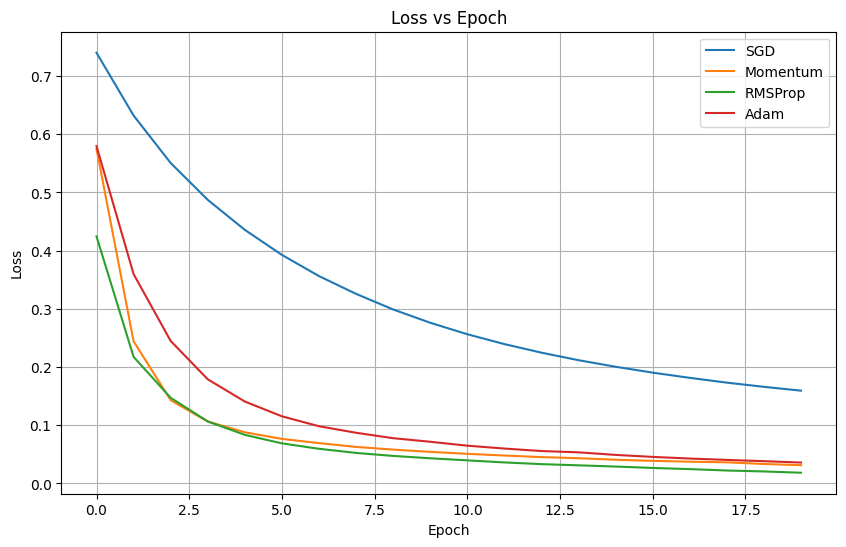

In [3]:
#SHAILESH GOWTHAM - 24BAD108

import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

optimizers = {
    "SGD": tf.keras.optimizers.SGD(),
    "Momentum": tf.keras.optimizers.SGD(momentum=0.9),
    "RMSProp": tf.keras.optimizers.RMSprop(),
    "Adam": tf.keras.optimizers.Adam()
}

plt.figure(figsize=(10,6))

for name, optimizer in optimizers.items():

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(30,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    plt.plot(history.history['loss'], label=name)

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(name)
    print("Test Accuracy:", accuracy)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# **PART D – Deep Learning Experiment Management**

In [4]:
#SHAILESH GOWTHAM - 24BAD108
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:

model.save('/content/drive/MyDrive/ANN_Model.h5')

In [8]:
!git clone https://github.com/jackso1328/24ADI006-Deep-Learning.git

Cloning into '24ADI006-Deep-Learning'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 30 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 1.24 MiB | 5.70 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [9]:
!cp "/content/drive/MyDrive/Colab Notebooks/DL_LAB_2.ipynb" "/content/24ADI006-Deep-Learning/Lab 2/"

cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/DL_LAB_2.ipynb': No such file or directory


In [10]:
!ls "/content/24ADI006-Deep-Learning/Lab 2"

ANN_Model.h5  DL_LAB_2.ipynb  readme.md


In [11]:
%cd "/content/24ADI006-Deep-Learning"

/content/24ADI006-Deep-Learning


In [12]:
!git config --global user.name "jackso1328"
!git config --global user.email "jackso1328@gmail.com"

In [13]:
!git add .
!git commit -m "Added DL Lab 2 notebook"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
